In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

Rows / columns:187,531 rows, 21 columns

Numeric vs text: numeric ==> Index, Price (in rupees), Dimensions, Plot Area

text ==> Everything else

Most missing:Plot Area and Dimensions are 100%
Society 58.5%, Super Area 57.4%, Car Parking 55.1%, overlooking 3.4% and Carpet Area 43.0%


In [6]:
def parse_amount(x):
    """Convert strings like '42 Lac' / '1.2 Cr' into a rupee amount."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

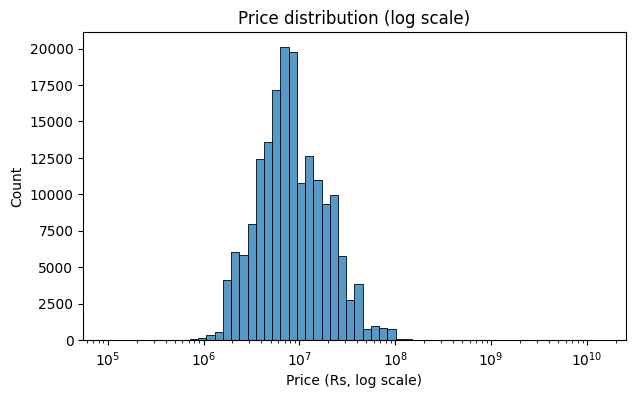

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.histplot(df["price_clean"].dropna(), log_scale=True, bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (Rs, log scale)")
plt.show()

In [8]:
def quick_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().replace(",", "").strip()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
    except ValueError:
        return None
    return None

df["_carpet_tmp"] = df["Carpet Area"].apply(quick_area)

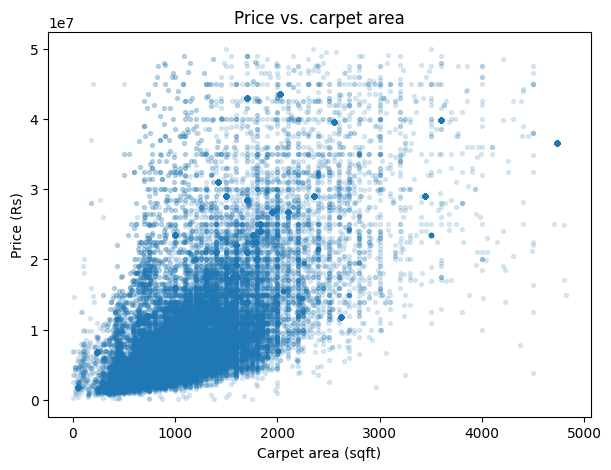

In [9]:
plt.figure(figsize=(7, 5))
sample = df.dropna(subset=["_carpet_tmp", "price_clean"])
sample = sample[(sample["_carpet_tmp"] < 5000) & (sample["price_clean"] < 5e7)]
plt.scatter(sample["_carpet_tmp"], sample["price_clean"], alpha=0.15, s=8)
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (Rs)")
plt.title("Price vs. carpet area")
plt.show()

In [10]:
df = df.drop(columns=["_carpet_tmp"])

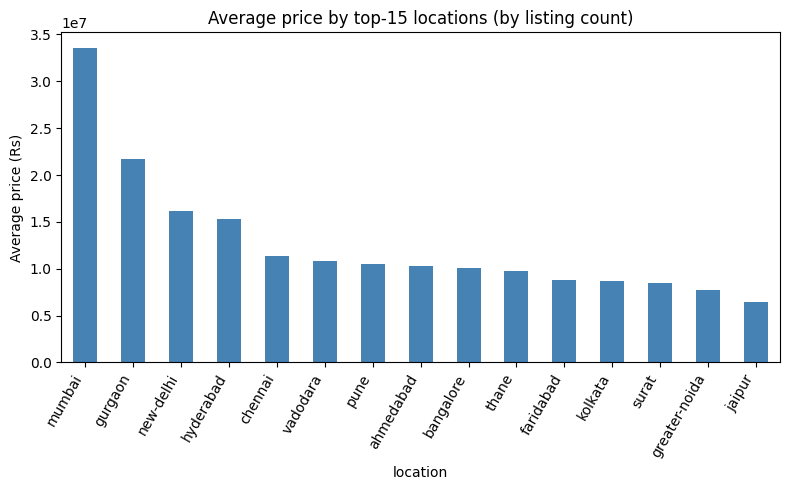

In [11]:
top_locations = df["location"].value_counts().head(15).index
avg_price_by_loc = (
    df[df["location"].isin(top_locations)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_price_by_loc.plot(kind="bar", color="steelblue")
plt.ylabel("Average price (Rs)")
plt.title("Average price by top-15 locations (by listing count)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

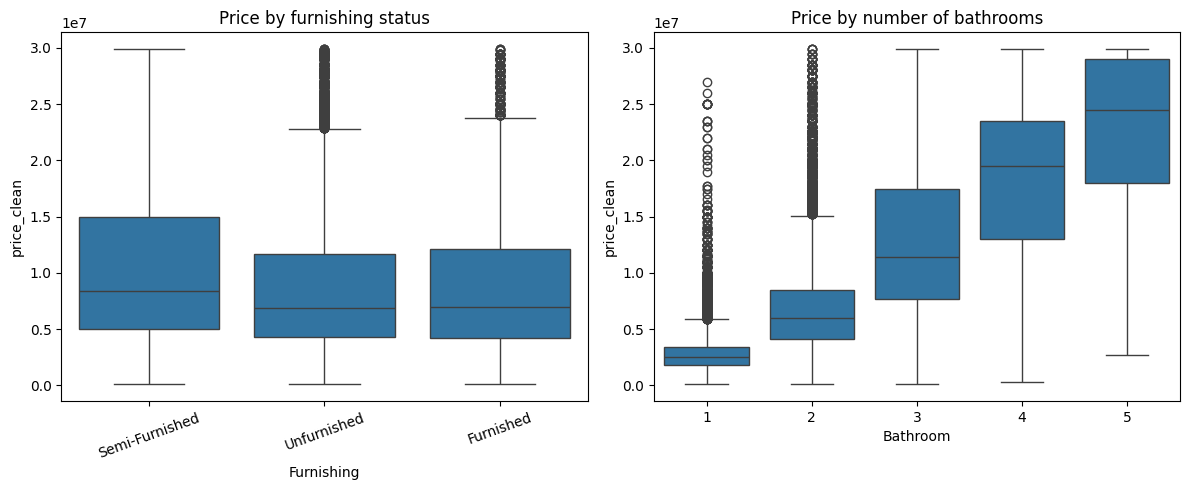

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

furn_order = df["Furnishing"].value_counts().index
sns.boxplot(data=df[df["price_clean"] < 3e7], x="Furnishing", y="price_clean",
            order=furn_order, ax=axes[0])
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis='x', rotation=20)

bath_subset = df[(df["price_clean"] < 3e7) & (df["Bathroom"].isin(["1","2","3","4","5"]))]
sns.boxplot(data=bath_subset, x="Bathroom", y="price_clean",
            order=["1","2","3","4","5"], ax=axes[1])
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

In [13]:
df = df.dropna(subset=["price_clean"])

In [14]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().replace(",", "").strip()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])


In [15]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    part = x.split("out of")[0].strip().lower()
    if part == "ground":
        return 0
    if part == "basement":
        return -1
    try:
        return int(part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [16]:
def parse_count(x, cap_value=11):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.startswith(">"):
        return cap_value
    try:
        return float(x)
    except ValueError:
        return None

df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)
df["balcony"] = df["balcony"].fillna(0)


In [17]:
TOP_N_LOCATIONS = 50
top_locs = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locs), other="other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

In [18]:
df = df.drop(columns=[
    "Index", "Title", "Description", "Dimensions", "Plot Area",
    "Society", "Carpet Area", "Super Area", "Floor", "Bathroom", "Balcony",
    "location", "Price (in rupees)", "super_area_sqft",
])
df.shape

(177847, 14)

In [19]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

valid_ppsf = df["price_per_sqft"].replace([np.inf, -np.inf], np.nan).dropna()
low, high = valid_ppsf.quantile([0.01, 0.99])
print(f"Keeping listings with price/sqft between Rs {low:,.0f} and Rs {high:,.0f}")

before = len(df)
mask = df["price_per_sqft"].between(low, high) | df["price_per_sqft"].isna()
df = df[mask].drop(columns=["price_per_sqft"])
print(f"Dropped {before - len(df):,} outlier rows -> {len(df):,} rows remain")

Keeping listings with price/sqft between Rs 2,255 and Rs 33,882
Dropped 3,381 outlier rows -> 174,466 rows remain


In [20]:
before = len(df)
carpet_low, carpet_high = df["carpet_area_sqft"].quantile([0.005, 0.995])
df = df[df["carpet_area_sqft"].between(carpet_low, carpet_high) | df["carpet_area_sqft"].isna()]
df = df[(df["floor_num"] <= 60) | df["floor_num"].isna()]
print(f"carpet_area_sqft capped to [{carpet_low:.0f}, {carpet_high:.0f}] sqft, floor_num capped to <= 60")
print(f"Dropped {before - len(df):,} more outlier rows -> {len(df):,} rows remain")

carpet_area_sqft capped to [323, 4583] sqft, floor_num capped to <= 60
Dropped 1,491 more outlier rows -> 172,975 rows remain


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(X, y, y_log, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((138380, 9), (34595, 9))

In [22]:
linreg = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=10.0)),
])
linreg.fit(X_train, y_train_log)  # trained on log1p(price)

# Stronger model
rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)),
])
rf.fit(X_train, y_train_log)  # trained on log1p(price)

print("Both models trained (on log1p(price)).")

Both models trained (on log1p(price)).


In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(model, name):
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)          # invert log1p back to rupees
    actual = y_test

    mae = mean_absolute_error(actual, pred)
    rmse = root_mean_squared_error(actual, pred)
    r2 = r2_score(actual, pred)
    print(f"{name:>20s} | MAE: Rs {mae:,.0f} | RMSE: Rs {rmse:,.0f} | R2: {r2:.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "pred": pred}

results = []
results.append(evaluate(linreg, "Ridge (linear)"))
results.append(evaluate(rf, "RandomForest"))

      Ridge (linear) | MAE: Rs 3,813,878 | RMSE: Rs 9,091,887 | R2: 0.356
        RandomForest | MAE: Rs 1,153,929 | RMSE: Rs 3,231,044 | R2: 0.919


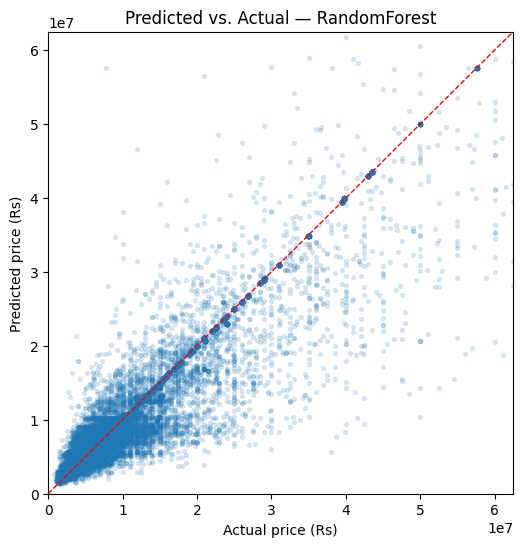

In [25]:
best = max(results, key=lambda r: r["R2"])
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best["pred"], alpha=0.15, s=8)
lims = [0, y_test.quantile(0.99)]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual price (Rs)")
plt.ylabel("Predicted price (Rs)")
plt.title(f"Predicted vs. Actual — {best['model']}")
plt.show()

In [26]:
import joblib

class LogTargetRegressor:
    """Wraps a pipeline trained on log1p(y) so .predict() returns real-scale values."""
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def predict(self, X):
        return np.expm1(self.pipeline.predict(X))

final_model = LogTargetRegressor(rf)

joblib.dump(final_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction: Rs {:,.0f}".format(loaded.predict(sample)[0]))
print("Actual price:        Rs {:,.0f}".format(y_test.iloc[0]))

Reloaded prediction: Rs 21,000,599
Actual price:        Rs 21,000,000


In [27]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
    indent=2,
)
print("Saved locations.json with", df["location_grouped"].nunique(), "locations")

Saved locations.json with 51 locations


In [29]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("--> Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.7.0
--> Pin this exact version in backend/requirements.txt
